Sales Summary:
   product  total_qty  revenue
0   Apples         25     12.5
1  Bananas         15      4.5
2  Oranges         15      9.0


<Figure size 800x500 with 0 Axes>

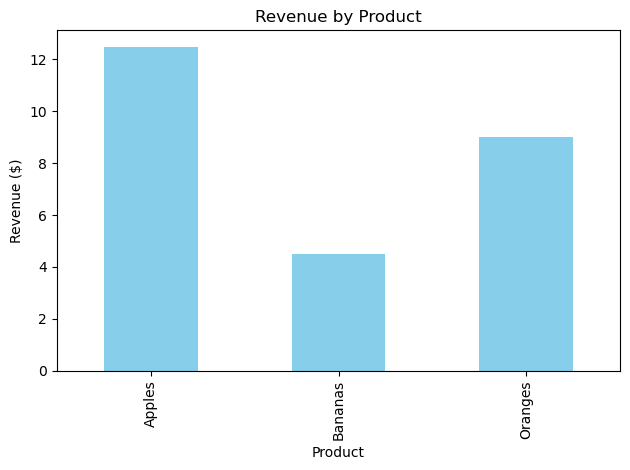

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create and populate the database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Drop table if exists (for repeatability)
cursor.execute("DROP TABLE IF EXISTS sales")

# Create table
cursor.execute("""
CREATE TABLE sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sales_data = [
    ('Apples', 10, 0.5),
    ('Bananas', 5, 0.3),
    ('Oranges', 8, 0.6),
    ('Apples', 15, 0.5),
    ('Bananas', 10, 0.3),
    ('Oranges', 7, 0.6)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)
conn.commit()

# Step 2: Query the data
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    ROUND(SUM(quantity * price), 2) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)
print("Sales Summary:")
print(df)

# Step 3: Plot the revenue
plt.figure(figsize=(8,5))
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

# Close the connection
conn.close()
